# Predicting Hepatitis C 🩺

#### If you like my work, It will be really great of you to upvote this notebook!
#### If not then you leaving a comment on what do I need to work on and improve will be really helpful!

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score

# Load your data
df = pd.read_csv("dataset-uci.csv")

# Separate labels and features
y = df["Gallstone Status"]
X = df.drop(columns=["Gallstone Status"])

# Optionally exclude engineered features (if they have specific prefixes or names)
# For now, we'll include everything and you can manually filter
# To include only original features, filter like:
# original_features = X[[col for col in X.columns if col not in ['InsulinResistance', 'BMIInsulinInteraction', ...]]]

# Scale numeric features
X_scaled = StandardScaler().fit_transform(X)

# Fit logistic regression with cross-validation
model = LogisticRegression(max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(model, X_scaled, y, cv=cv)

# Fit to get coefficients
model.fit(X_scaled, y)
coefficients = pd.Series(model.coef_[0], index=X.columns)

# Rank by importance
important_features = coefficients.abs().sort_values(ascending=False)
top_features = important_features.head(15).index.tolist()

print("\nTop Predictive Features for Logistic Regression:")
print(coefficients[top_features].sort_values(key=lambda x: abs(x), ascending=False))

# Print logistic regression accuracy
print("\nLogistic Regression Accuracy:", accuracy_score(y, y_pred))



Top Predictive Features for Logistic Regression:
C-Reactive Protein (CRP)                          1.637480
Bone Mass (BM)                                   -1.442332
Intracellular Water (ICW)                         1.108890
Gender                                           -0.987120
Vitamin D                                        -0.887132
Total Body Fat Ratio (TBFR) (%)                   0.860253
Hyperlipidemia                                    0.855643
Aspartat Aminotransferaz (AST)                   -0.844768
Extracellular Fluid/Total Body Water (ECF/TBW)   -0.775944
Total Fat Content (TFC)                          -0.719765
Diabetes Mellitus (DM)                            0.627694
Hemoglobin (HGB)                                 -0.627615
Age                                               0.587283
Alanin Aminotransferaz (ALT)                      0.570806
Lean Mass (LM) (%)                               -0.497331
dtype: float64

Logistic Regression Accuracy: 0.7774294670846394


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

   Gallstone Status  C-Reactive Protein (CRP)  Bone Mass (BM)  \
0                 0                       0.0             3.7   
1                 0                       0.0             3.2   
2                 0                       0.0             3.3   
3                 0                       0.0             2.9   
4                 0                       0.0             3.5   

   Intracellular Water (ICW)  Gender  Vitamin D  \
0                       31.7       0       33.0   
1                       23.6       0       25.0   
2                       27.1       0       30.2   
3                       24.4       0       35.4   
4                       31.4       0       40.6   

   Total Body Fat Ratio (TBFR) (%)  Hyperlipidemia  \
0                             19.2               0   
1                             32.8               0   
2                             27.3               0   
3                             15.8               0   
4                             20

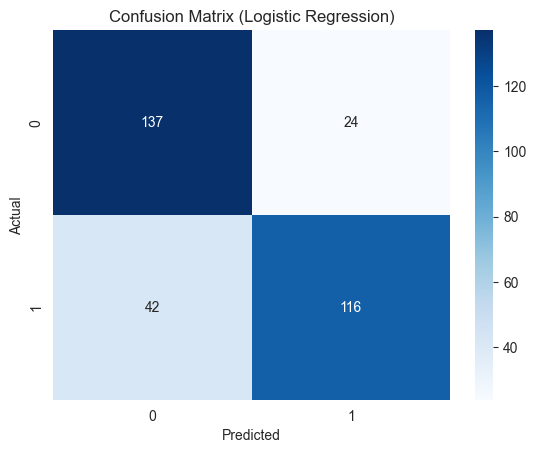

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       161
           1       0.83      0.73      0.78       158

    accuracy                           0.79       319
   macro avg       0.80      0.79      0.79       319
weighted avg       0.80      0.79      0.79       319



In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("dataset-uci.csv")  # replace with your path

df['HDL_High'] = (df['High Density Lipoprotein (HDL)'] >= 50).astype(int)

# BMI < 25 → normal weight
df['BMI_Normal'] = (df['Body Mass Index (BMI)'] < 25).astype(int)



df['BMI_Over25'] = (df['Body Mass Index (BMI)'] >= 25).astype(int)


df['LiverStress'] = (
    (df['Alanin Aminotransferaz (ALT)'] > 40).astype(int) |
    (df['Aspartat Aminotransferaz (AST)'] > 35).astype(int) |
    (df['Alkaline Phosphatase (ALP)'] > 120).astype(int)
)

columns_to_keep = [
    "Gallstone Status",
    "C-Reactive Protein (CRP)",
    "Bone Mass (BM)",
    "Intracellular Water (ICW)",
    "Gender",
    "Vitamin D",
    "Total Body Fat Ratio (TBFR) (%)",
    "Hyperlipidemia",
    "Aspartat Aminotransferaz (AST)",
    "Extracellular Fluid/Total Body Water (ECF/TBW)",
    "Total Fat Content (TFC)",
    "Diabetes Mellitus (DM)",
    "Hemoglobin (HGB)",
    "Age",
    "Alanin Aminotransferaz (ALT)",
    "Lean Mass (LM) (%)"
]

df = df[columns_to_keep]




# df['AtherogenicIndex'] = np.log10(df['Triglyceride'] / (df['High Density Lipoprotein (HDL)'] + 1e-3))


# HDL ≥ 50 → good cholesterol




# Preview
print(df.head())
print(df['Gallstone Status'].value_counts())
X = df.drop(columns=['Gallstone Status'])  # target column assumed to be 'Gallstones'
y = df['Gallstone Status']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=1000)

y_pred = cross_val_predict(model, X_scaled, y, cv=cv)
acc = accuracy_score(y, y_pred)
print(f"Stratified Logistic Regression Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

print("Classification Report:")
print(classification_report(y, y_pred))

In [2]:
# Get prediction vs actual
df['y_true'] = y
df['y_pred'] = y_pred

# Filter false negatives
fn_cases = df[(df['y_true'] == 1) & (df['y_pred'] == 0)]


In [3]:
fn_cases.describe()


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D,HDL_High,BMI_Normal,BMI_Over25,LiverStress,y_true,y_pred
count,36.0,36.000000,36.000000,36.000000,36.000000,36.000000,36.0,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.0,36.0
mean,1.0,45.638889,0.388889,0.361111,0.027778,0.055556,0.0,0.166667,167.777778,80.647222,...,101.501185,1.042778,14.698611,23.026389,0.361111,0.194444,0.805556,0.250000,1.0,0.0
std,0.0,10.970487,0.494413,0.487136,0.166667,0.232311,0.0,0.377964,9.472098,14.526576,...,14.544574,1.476151,1.620691,9.302968,0.487136,0.401386,0.401386,0.439155,0.0,0.0
min,1.0,24.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,150.000000,53.400000,...,66.900000,0.000000,10.300000,5.700000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
25%,1.0,36.500000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,160.000000,68.200000,...,92.797000,0.000000,13.975000,17.937500,0.000000,0.000000,1.000000,0.000000,1.0,0.0
50%,1.0,46.500000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,168.500000,79.300000,...,101.300000,0.300000,14.700000,22.650000,0.000000,0.000000,1.000000,0.000000,1.0,0.0
75%,1.0,55.250000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,175.000000,92.425000,...,112.009667,1.300000,16.000000,28.675000,1.000000,0.000000,1.000000,0.250000,1.0,0.0
max,1.0,67.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,188.000000,116.100000,...,128.500000,5.800000,18.200000,44.700000,1.000000,1.000000,1.000000,1.000000,1.0,0.0


/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_90473/1578694179.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette='mako')


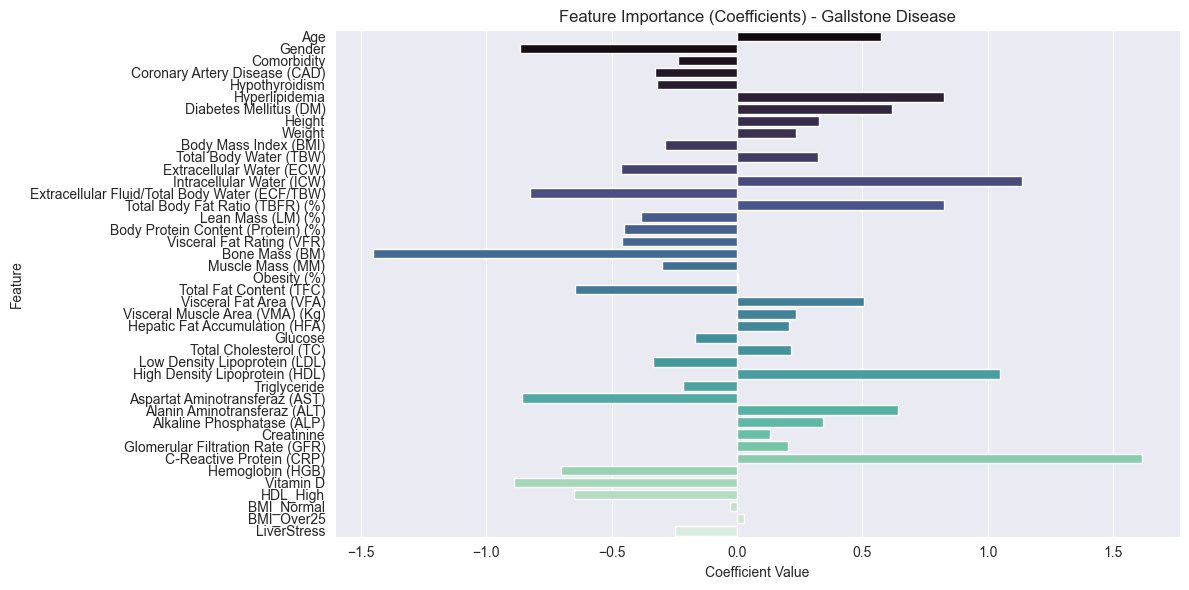

ModuleNotFoundError: No module named 'shap'

In [4]:
# Feature Importance (Coefficients)
model.fit(X_scaled, y)
importance = model.coef_[0]
features = X.columns
plt.figure(figsize=(12, 6))
sns.barplot(x=importance, y=features, palette='mako')
plt.title("Feature Importance (Coefficients) - Gallstone Disease")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# SHAP Values for Interpretability
import shap
explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer.shap_values(X_scaled)
shap.summary_plot(shap_values, features=X.columns, plot_type="bar")

# Predicted Probability Distribution
y_proba = cross_val_predict(model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
plt.figure(figsize=(8, 6))
sns.histplot(y_proba, bins=30, kde=True, color='teal')
plt.title('Predicted Probability Distribution - Gallstone Disease')
plt.xlabel('Probability of Gallstones')
plt.ylabel('Frequency')
plt.show()
